In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install timm mediapipe opencv-python tqdm scikit-learn numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import os

CELEBDF_ROOT = "/content/drive/MyDrive/Celeb-DF-v2"

REAL_DIR = os.path.join(CELEBDF_ROOT, "Celeb-real")
FAKE_DIR = os.path.join(CELEBDF_ROOT, "Celeb-synthesis")

real_videos = [os.path.join(REAL_DIR, f) for f in os.listdir(REAL_DIR) if f.endswith(".mp4")]
fake_videos = [os.path.join(FAKE_DIR, f) for f in os.listdir(FAKE_DIR) if f.endswith(".mp4")]

print("Real videos:", len(real_videos))
print("Fake videos:", len(fake_videos))


KeyboardInterrupt: 

In [ ]:
import cv2
import mediapipe as mp

mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(
    model_selection=1,
    min_detection_confidence=0.5
)
def extract_face(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_detector.process(rgb)

    if not results.detections:
        return None

    h, w, _ = frame.shape
    bbox = results.detections[0].location_data.relative_bounding_box

    x1 = int(bbox.xmin * w)
    y1 = int(bbox.ymin * h)
    x2 = int((bbox.xmin + bbox.width) * w)
    y2 = int((bbox.ymin + bbox.height) * h)

    face = frame[y1:y2, x1:x2]
    if face.size == 0:
        return None

    return cv2.resize(face, (224, 224))

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
import mediapipe as mp
print(mp.__version__)
print(dir(mp))


0.10.31
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [ ]:
!wget -O face_detector.tflite https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite


--2026-01-15 05:02:04--  https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.202.207, 173.194.203.207, 74.125.199.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.202.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 229746 (224K) [application/octet-stream]
Saving to: ‘face_detector.tflite’

face_detector.tflit 100%[===================>] 224.36K  --.-KB/s    in 0.003s  

2026-01-15 05:02:04 (86.2 MB/s) - ‘face_detector.tflite’ saved [229746/229746]



In [ ]:
import os
os.path.exists("face_detector.tflite")


True

In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Load model
base_options = python.BaseOptions(model_asset_path="face_detector.tflite")

options = vision.FaceDetectorOptions(
    base_options=base_options,
    min_detection_confidence=0.5
)

detector = vision.FaceDetector.create_from_options(options)


In [ ]:
def extract_face(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    result = detector.detect(mp_image)

    if not result.detections:
        return None

    bbox = result.detections[0].bounding_box
    x, y, w, h = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height

    h_img, w_img, _ = frame.shape
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(w_img, x + w)
    y2 = min(h_img, y + h)

    face = frame[y1:y2, x1:x2]
    if face.size == 0:
        return None

    return cv2.resize(face, (224, 224))


In [ ]:
pip install torch torchvision timm opencv-python mediapipe scikit-learn numpy tqdm


In [ ]:
import os

CELEB_DF_ROOT = "/content/drive/MyDrive/Celeb-DF-v2"

REAL_DIR  = os.path.join(CELEB_DF_ROOT, "Celeb-real")
FAKE_DIR  = os.path.join(CELEB_DF_ROOT, "Celeb-synthesis")

real_videos = [os.path.join(REAL_DIR, v) for v in os.listdir(REAL_DIR)]
fake_videos = [os.path.join(FAKE_DIR, v) for v in os.listdir(FAKE_DIR)]

video_paths = real_videos + fake_videos
labels = [0]*len(real_videos) + [1]*len(fake_videos)  # 0=real, 1=fake

print("Total videos:", len(video_paths))
print("Real:", len(real_videos), "Fake:", len(fake_videos))


Total videos: 6229
Real: 590 Fake: 5639


In [ ]:
import torch
import timm
import mediapipe as mp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("efficientnet_b0", pretrained=True)
model.classifier = torch.nn.Identity()
model.eval().to(device)

mp_face = mp.solutions.face_detection.FaceDetection(
    model_selection=1, min_detection_confidence=0.5
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.9


Found existing installation: mediapipe 0.10.31
Uninstalling mediapipe-0.10.31:
  Successfully uninstalled mediapipe-0.10.31
ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31)
ERROR: No matching distribution found for mediapipe==0.10.9


In [ ]:
!pip install mediapipe==0.10.31


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


In [ ]:
!wget -q https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/latest/blaze_face_short_range.tflite


In [ ]:
!ls blaze_face_short_range.tflite


blaze_face_short_range.tflite


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path="blaze_face_short_range.tflite"
)

options = vision.FaceDetectorOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_detection_confidence=0.5
)

face_detector = vision.FaceDetector.create_from_options(options)


In [ ]:
import cv2

def detect_face(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = face_detector.detect(mp_image)
    if not result.detections:
        return None

    bbox = result.detections[0].bounding_box
    h, w, _ = frame.shape

    x1 = max(bbox.origin_x, 0)
    y1 = max(bbox.origin_y, 0)
    x2 = min(x1 + bbox.width, w)
    y2 = min(y1 + bbox.height, h)

    face = frame[y1:y2, x1:x2]
    if face.size == 0:
        return None

    return cv2.resize(face, (224, 224))


Face detected: True


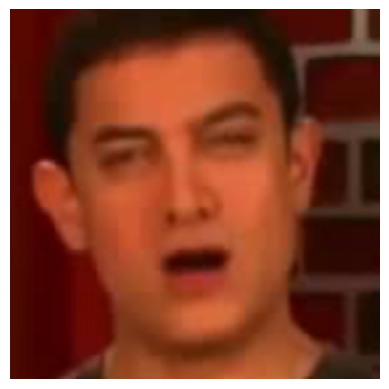

In [ ]:
import cv2
import matplotlib.pyplot as plt

# pick any video from Celeb-DF-v2
test_video = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id0_0000.mp4"

cap = cv2.VideoCapture(test_video)
ret, frame = cap.read()
cap.release()

face = detect_face(frame)

print("Face detected:", face is not None)

if face is not None:
    plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    plt.axis("off")


In [ ]:
import os

CELEB_DF_ROOT = "/content/drive/MyDrive/Celeb-DF-v2"

REAL_DIR = os.path.join(CELEB_DF_ROOT, "Celeb-real")
FAKE_DIR = os.path.join(CELEB_DF_ROOT, "Celeb-synthesis")

real_videos = [
    os.path.join(REAL_DIR, f)
    for f in os.listdir(REAL_DIR)
    if f.endswith(".mp4")
]

fake_videos = [
    os.path.join(FAKE_DIR, f)
    for f in os.listdir(FAKE_DIR)
    if f.endswith(".mp4")
]

video_paths = real_videos + fake_videos
labels = [0]*len(real_videos) + [1]*len(fake_videos)

print("Total videos:", len(video_paths))
print("Real:", len(real_videos))
print("Fake:", len(fake_videos))


Total videos: 6229
Real: 590
Fake: 5639


In [ ]:
import torch
import timm

# -------------------------------
# Device (GPU / CPU)
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# EfficientNet-B0 (feature extractor)
# -------------------------------
model = timm.create_model("efficientnet_b0", pretrained=True)
model.classifier = torch.nn.Identity()   # remove classifier
model.eval().to(device)


Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
import cv2
import numpy as np
import torch
from torchvision import transforms

# -------------------------------
# Frame extraction
# -------------------------------
def extract_frames(video_path, fps=5):
    cap = cv2.VideoCapture(video_path)   # FIXED
    frames = []

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    if video_fps == 0:
        cap.release()
        return frames

    step = max(int(video_fps // fps), 1)

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            frames.append(frame)
        idx += 1

    cap.release()
    return frames


# -------------------------------
# Spatial feature extraction
# -------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def extract_spatial_features(frames):
    feats = []
    with torch.no_grad():
        for frame in frames:
            face = detect_face(frame)
            if face is None:
                continue
            x = transform(face).unsqueeze(0).to(device)
            feat = model(x).squeeze(0).cpu().numpy()
            feats.append(feat)
    return np.array(feats)


# -------------------------------
# Temporal beta features
# -------------------------------
def beta_features(embeddings):
    betas = [0.0]
    for i in range(1, len(embeddings)):
        betas.append(np.linalg.norm(embeddings[i] - embeddings[i-1]))
    return np.array(betas)


# -------------------------------
# Sliding window + Hanning
# -------------------------------
def sliding_window_features(embeds, betas, win=10, stride=5):
    features = []
    for i in range(0, len(embeds) - win + 1, stride):
        e = embeds[i:i+win]
        b = betas[i:i+win]

        w = np.hanning(win)
        w = w / w.sum()

        spatial = np.sum(e * w[:, None], axis=0)
        temporal = [
            np.mean(b),
            np.std(b),
            np.median(b)
        ]

        features.append(np.concatenate([spatial, temporal]))
    return np.array(features)


# -------------------------------
# Video-level representation
# -------------------------------
def video_representation(video_path):
    frames = extract_frames(video_path)   # FIXED
    embeds = extract_spatial_features(frames)

    if len(embeds) < 10:
        return None

    betas = beta_features(embeds)
    win_feats = sliding_window_features(embeds, betas)

    if len(win_feats) == 0:
        return None

    return np.mean(win_feats, axis=0)


In [ ]:
from tqdm import tqdm

X, y = [], []

for path, label in tqdm(zip(video_paths, labels), total=len(video_paths)):
    feat = video_representation(path)
    if feat is None:
        continue
    X.append(feat)
    y.append(label)

X = np.array(X)
y = np.array(y)

np.save("features.npy", X)
np.save("labels.npy", y)

print("Saved features:", X.shape)


NameError: name 'video_paths' is not defined

In [ ]:
import numpy as np

X = np.load("features.npy")
y = np.load("labels.npy")

print("Loaded features:", X.shape)
print("Loaded labels:", y.shape)
print("Real:", np.sum(y == 0), "Fake:", np.sum(y == 1))


FileNotFoundError: [Errno 2] No such file or directory: 'features.npy'

In [ ]:
!find /content/drive -name "features.npy"
!find /content/drive -name "labels.npy"


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/celebdf_features"


In [ ]:
!ls /content/drive/MyDrive/celebdf_features


features.npy  labels.npy  last_index.txt


In [ ]:
import os
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/celebdf_features"
os.makedirs(SAVE_DIR, exist_ok=True)

FEATURE_FILE = os.path.join(SAVE_DIR, "features.npy")
LABEL_FILE   = os.path.join(SAVE_DIR, "labels.npy")
INDEX_FILE   = os.path.join(SAVE_DIR, "last_index.txt")


In [ ]:
if os.path.exists(FEATURE_FILE) and os.path.exists(LABEL_FILE):
    X = list(np.load(FEATURE_FILE))
    y = list(np.load(LABEL_FILE))
    start_idx = int(open(INDEX_FILE).read())
    print(f"Resuming from index {start_idx}")
else:
    X, y = [], []
    start_idx = 0
    print("Starting fresh extraction")


Starting fresh extraction


In [ ]:
import os

CELEB_DF_ROOT = "/content/drive/MyDrive/Celeb-DF-v2"

REAL_DIR = os.path.join(CELEB_DF_ROOT, "Celeb-real")
FAKE_DIR = os.path.join(CELEB_DF_ROOT, "Celeb-synthesis")

real_videos = [
    os.path.join(REAL_DIR, f)
    for f in os.listdir(REAL_DIR)
    if f.endswith(".mp4")
]

fake_videos = [
    os.path.join(FAKE_DIR, f)
    for f in os.listdir(FAKE_DIR)
    if f.endswith(".mp4")
]

video_paths = real_videos + fake_videos
labels = [0] * len(real_videos) + [1] * len(fake_videos)

print("Total videos:", len(video_paths))
print("Real:", len(real_videos))
print("Fake:", len(fake_videos))


Total videos: 6229
Real: 590
Fake: 5639


In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ----------------------------------
# Load MediaPipe face detector model
# ----------------------------------
MODEL_PATH = "/content/blaze_face_short_range.tflite"

if not os.path.exists(MODEL_PATH):
    !wget -q https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/latest/blaze_face_short_range.tflite

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.FaceDetectorOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_detection_confidence=0.5
)

face_detector = vision.FaceDetector.create_from_options(options)

# ----------------------------------
# Face detection function
# ----------------------------------
def detect_face(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = face_detector.detect(mp_image)
    if not result.detections:
        return None

    bbox = result.detections[0].bounding_box
    h, w, _ = frame.shape

    x1 = max(int(bbox.origin_x), 0)
    y1 = max(int(bbox.origin_y), 0)
    x2 = min(x1 + int(bbox.width), w)
    y2 = min(y1 + int(bbox.height), h)

    face = frame[y1:y2, x1:x2]
    if face.size == 0:
        return None

    return cv2.resize(face, (224, 224))


In [ ]:
import os
import numpy as np

# Paths (must match earlier)
SAVE_DIR = "/content/drive/MyDrive/celebdf_features"
FEATURE_FILE = os.path.join(SAVE_DIR, "features.npy")
LABEL_FILE   = os.path.join(SAVE_DIR, "labels.npy")
INDEX_FILE   = os.path.join(SAVE_DIR, "last_index.txt")

# Load checkpoint
if os.path.exists(FEATURE_FILE) and os.path.exists(LABEL_FILE) and os.path.exists(INDEX_FILE):
    X = list(np.load(FEATURE_FILE))
    y = list(np.load(LABEL_FILE))
    start_idx = int(open(INDEX_FILE).read())
    print(f"Resuming from index {start_idx}")
    print("Already extracted features:", len(X))
else:
    X, y = [], []
    start_idx = 0
    print("No checkpoint found, starting from scratch")


Resuming from index 1700
Already extracted features: 1680


In [ ]:
from tqdm import tqdm

for i in tqdm(range(start_idx, len(video_paths))):
    path = video_paths[i]
    label = labels[i]

    feat = video_representation(path)
    if feat is None:
        continue

    X.append(feat)
    y.append(label)

    if i % 25 == 0:
        np.save(FEATURE_FILE, np.array(X))
        np.save(LABEL_FILE, np.array(y))
        with open(INDEX_FILE, "w") as f:
            f.write(str(i))


100%|██████████| 4529/4529 [7:14:08<00:00,  5.75s/it]


In [ ]:
import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/celebdf_features"

X = np.load(os.path.join(SAVE_DIR, "features.npy"))
y = np.load(os.path.join(SAVE_DIR, "labels.npy"))

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("Real:", (y == 0).sum(), "Fake:", (y == 1).sum())


Features shape: (6206, 1283)
Labels shape: (6206,)
Real: 586 Fake: 5620


In [ ]:
from sklearn.model_selection import train_test_split

# 70% train
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(y_train))
print("Val:", len(y_val))
print("Test:", len(y_test))


Train: 4344
Val: 931
Test: 931


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95,   # retain 95% variance
    whiten=True,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

print("PCA reduced dimension:", X_train_pca.shape[1])


PCA reduced dimension: 167


In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train_pca, y_train)


SVC(C=10, probability=True, random_state=42)

In [ ]:
import joblib

joblib.dump(pca, os.path.join(SAVE_DIR, "pca_95.joblib"))
joblib.dump(svm, os.path.join(SAVE_DIR, "svm_rbf.joblib"))


['/content/drive/MyDrive/celebdf_features/svm_rbf.joblib']

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Validation
val_probs = svm.predict_proba(X_val_pca)[:, 1]
val_preds = svm.predict(X_val_pca)

# Test
test_probs = svm.predict_proba(X_test_pca)[:, 1]
test_preds = svm.predict(X_test_pca)

print("Validation AUC:", roc_auc_score(y_val, val_probs))
print("Test AUC:", roc_auc_score(y_test, test_probs))
print("Test Accuracy:", accuracy_score(y_test, test_preds))

print("\nTest Classification Report:")
print(classification_report(y_test, test_preds, digits=4))


Validation AUC: 0.9336784212229052
Test AUC: 0.9406206190014019
Test Accuracy: 0.9484425349087003

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9000    0.5114    0.6522        88
           1     0.9512    0.9941    0.9722       843

    accuracy                         0.9484       931
   macro avg     0.9256    0.7527    0.8122       931
weighted avg     0.9464    0.9484    0.9419       931



In [ ]:
import torch
import torch.nn.functional as F
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("efficientnet_b0", pretrained=True)
model.eval().to(device)

# We will hook the last convolutional block
target_layer = model.conv_head


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output.mean()   # feature-level objective
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam


In [ ]:
import cv2
import numpy as np
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

gradcam = GradCAM(model, target_layer)

def generate_heatmap(face_img):
    x = transform(face_img).unsqueeze(0).to(device)
    cam = gradcam.generate(x)

    heatmap = cam[0].cpu().numpy()
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(face_img, 0.6, heatmap, 0.4, 0)
    return overlay


In [ ]:
import matplotlib.pyplot as plt

def heatmaps_from_video(video_path, num_frames=5):
    frames = extract_frames(video_path, fps=5)
    count = 0

    for frame in frames:
        face = detect_face(frame)
        if face is None:
            continue

        heatmap = generate_heatmap(face)

        plt.figure(figsize=(3,3))
        plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

        count += 1
        if count == num_frames:
            break


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor):
        self.model.zero_grad()

        output = self.model(input_tensor)

        # Feature-level objective (correct for SVM pipeline)
        score = output.mean()
        score.backward()

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)

        cam = torch.relu(cam)

        # ---- numerical safety ----
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)

        return cam.detach()


In [ ]:
def generate_heatmap(face_img):
    x = transform(face_img).unsqueeze(0).to(device)
    cam = gradcam.generate(x)

    heatmap = cam[0].cpu().numpy()
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(face_img, 0.6, heatmap_color, 0.4, 0)

    return overlay


In [ ]:
def generate_heatmap(face_img, amplify=True):
    x = transform(face_img).unsqueeze(0).to(device)
    cam = gradcam.generate(x)

    heatmap = cam[0].cpu().numpy()

    # ---- contrast amplification (VISUALIZATION ONLY) ----
    if amplify:
        heatmap = heatmap ** 0.5   # gamma correction
        heatmap = np.clip(heatmap, 0, 1)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(face_img, 0.55, heatmap_color, 0.45, 0)
    return overlay


In [ ]:
target_layer = model.conv_head

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output.backward(torch.ones_like(output))

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        return cam


In [ ]:
def overlay_gradcam(face_img, cam):
    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)   # normalize safely

    cam = cv2.resize(cam, (face_img.shape[1], face_img.shape[0]))
    cam = np.uint8(255 * cam)

    heatmap = cv2.applyColorMap(cam, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(face_img, 0.6, heatmap, 0.4, 0)

    return overlay


In [ ]:
REAL_DIR = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real"
FAKE_DIR = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis"
cv2.imwrite(
    os.path.join(save_dir, out_name),
    cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
)


NameError: name 'out_name' is not defined

In [ ]:
print(len(os.listdir(REAL_DIR)), len(os.listdir(FAKE_DIR)))


590 5639


In [ ]:
print(overlay.shape, overlay.dtype)


NameError: name 'overlay' is not defined

In [ ]:
samples = [
    (0, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id0_0000.mp4"),
    (0, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id2_0002.mp4"),
    (0, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id11_0000.mp4"),
    (1, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis/id0_id16_0000.mp4"),
    (1, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis/id2_id16_0002.mp4"),
    (1, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis/id2_id16_0000.mp4"),
]


In [ ]:
import cv2
import os
import numpy as np

def get_middle_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return None

    mid_idx = total_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid_idx)

    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None

    return frame


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path="/content/face_detector.tflite"
)

detector_options = vision.FaceDetectorOptions(
    base_options=base_options
)

face_detector = vision.FaceDetector.create_from_options(detector_options)


In [ ]:
def extract_face(frame, margin=0.2, out_size=224):
    h, w, _ = frame.shape

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    )

    detection_result = face_detector.detect(mp_image)

    if not detection_result.detections:
        return None

    bbox = detection_result.detections[0].bounding_box

    x1 = int(bbox.origin_x)
    y1 = int(bbox.origin_y)
    bw = int(bbox.width)
    bh = int(bbox.height)

    x2 = x1 + bw
    y2 = y1 + bh

    # margin
    dx = int(bw * margin)
    dy = int(bh * margin)

    x1 = max(0, x1 - dx)
    y1 = max(0, y1 - dy)
    x2 = min(w, x2 + dx)
    y2 = min(h, y2 + dy)

    face = frame[y1:y2, x1:x2]
    if face.size == 0:
        return None

    face = cv2.resize(face, (out_size, out_size))
    return face


In [ ]:
import torch
from torchvision import transforms

preprocess_face = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
print(get_middle_frame(samples[0][1]).shape)
print(extract_face(get_middle_frame(samples[0][1])).shape)


(500, 942, 3)
(224, 224, 3)


In [ ]:
print(type(model))


<class 'timm.models.efficientnet.EfficientNet'>


In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import os

# ===============================
# CONFIG
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval().to(device)

SAVE_DIR = "/content/gradcam_final"
os.makedirs(SAVE_DIR, exist_ok=True)

# ===============================
# TARGET LAYER (EfficientNet)
# ===============================
target_layer = model.conv_head   # correct for timm EfficientNet

# ===============================
# HOOK STORAGE
# ===============================
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# ===============================
# PREPROCESS
# ===============================
def preprocess(face):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = face / 255.0
    face = torch.tensor(face).permute(2,0,1).unsqueeze(0).float()
    return face.to(device)

# ===============================
# GRAD-CAM FUNCTION
# ===============================
def generate_gradcam(face):
    activations.clear()
    gradients.clear()

    x = preprocess(face)
    out = model(x)

    score = out.mean()
    model.zero_grad()
    score.backward()

    A = activations[0]        # [1,C,H,W]
    G = gradients[0]          # [1,C,H,W]

    weights = G.mean(dim=(2,3), keepdim=True)
    cam = (weights * A).sum(dim=1, keepdim=True)

    cam = F.relu(cam)
    cam = cam.squeeze().detach().cpu().numpy()

    cam = cv2.resize(cam, (224,224))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    heatmap = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(
        cv2.cvtColor(face, cv2.COLOR_BGR2RGB),
        0.6,
        heatmap,
        0.4,
        0
    )

    return overlay

# ===============================
# SAMPLE VIDEOS (3 REAL + 3 FAKE)
# ===============================
samples = [
    (0, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id0_0000.mp4"),
    (0, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id11_0000.mp4"),
    (0, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id2_0002.mp4"),
    (1, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis/id0_id16_0000.mp4"),
    (1, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis/id11_id7_0000.mp4"),
    (1, "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis/id3_id6_0003.mp4"),
]

# ===============================
# GENERATE & SAVE
# ===============================
for idx, (label, video_path) in enumerate(samples):

    frame = get_middle_frame(video_path)
    if frame is None:
        continue

    face = extract_face(frame)
    if face is None:
        continue

    cam_img = generate_gradcam(face)

    name = f"{'real' if label==0 else 'fake'}_{idx}.png"
    cv2.imwrite(
        os.path.join(SAVE_DIR, name),
        cv2.cvtColor(cam_img, cv2.COLOR_RGB2BGR)
    )

print("✅ 6 Grad-CAM images generated and saved.")


✅ 6 Grad-CAM images generated and saved.


In [ ]:
import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/celebdf_features"

X = np.load(os.path.join(SAVE_DIR, "features.npy"))
y = np.load(os.path.join(SAVE_DIR, "labels.npy"))

print(X.shape, y.shape)


(6206, 1283) (6206,)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score


In [ ]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

auc_scores = []
acc_scores = []
pca_dims = []


In [ ]:
fold = 1

for train_idx, val_idx in skf.split(X, y):
    print(f"\n===== Fold {fold} =====")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ---- PCA (fit on train only) ----
    pca = PCA(
        n_components=0.95,
        whiten=True,
        random_state=42
    )

    X_train_pca = pca.fit_transform(X_train)
    X_val_pca   = pca.transform(X_val)

    print("PCA dims:", X_train_pca.shape[1])
    pca_dims.append(X_train_pca.shape[1])

    # ---- SVM ----
    svm = SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True,
        random_state=42
    )

    svm.fit(X_train_pca, y_train)

    # ---- Evaluation ----
    val_probs = svm.predict_proba(X_val_pca)[:, 1]
    val_preds = svm.predict(X_val_pca)

    auc = roc_auc_score(y_val, val_probs)
    acc = accuracy_score(y_val, val_preds)

    auc_scores.append(auc)
    acc_scores.append(acc)

    print(f"Fold {fold} AUC: {auc:.4f}")
    print(f"Fold {fold} ACC: {acc:.4f}")

    fold += 1



===== Fold 1 =====
PCA dims: 168
Fold 1 AUC: 0.9356
Fold 1 ACC: 0.9435

===== Fold 2 =====
PCA dims: 167
Fold 2 AUC: 0.9322
Fold 2 ACC: 0.9507

===== Fold 3 =====
PCA dims: 167
Fold 3 AUC: 0.9346
Fold 3 ACC: 0.9483


In [ ]:
print("\n===== 3-Fold Cross-Validation Results =====")
print("AUC per fold:", auc_scores)
print("Accuracy per fold:", acc_scores)

print(f"Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"Mean PCA dims: {int(np.mean(pca_dims))}")



===== 3-Fold Cross-Validation Results =====
AUC per fold: [np.float64(0.9356143151334213), np.float64(0.9322086309279479), np.float64(0.9345900584555149)]
Accuracy per fold: [0.943450942484292, 0.9507008216529724, 0.9482591876208898]
Mean AUC: 0.9341 ± 0.0014
Mean Accuracy: 0.9475 ± 0.0030
Mean PCA dims: 167


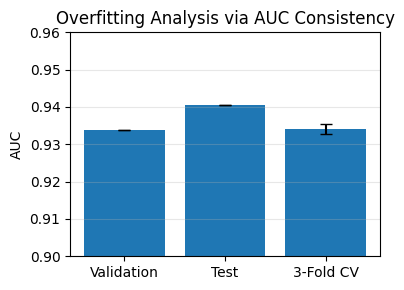

In [ ]:
import matplotlib.pyplot as plt

labels = ["Validation", "Test", "3-Fold CV"]
auc_values = [0.9337, 0.9406, 0.9341]
auc_std = [0.0, 0.0, 0.0014]

plt.figure(figsize=(4,3))
plt.bar(labels, auc_values, yerr=auc_std, capsize=4)
plt.ylabel("AUC")
plt.ylim(0.90, 0.96)
plt.title("Overfitting Analysis via AUC Consistency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import os

matches = []
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "effnet" in file.lower() and file.endswith(".npz"):
            matches.append(os.path.join(root, file))

matches


['/content/drive/MyDrive/patch_beta_v3_effnet_hann/features_effnet_hann_590.npz']

In [ ]:
import numpy as np

data = np.load(
    "/content/drive/MyDrive/patch_beta_v3_effnet_hann/features_effnet_hann_590.npz"
)

print("Keys in NPZ file:", data.files)


Keys in NPZ file: ['X', 'Y']


In [ ]:
import numpy as np

X = np.load("/content/drive/MyDrive/celebdf_features/features.npy")
y = np.load("/content/drive/MyDrive/celebdf_features/labels.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))
print("Real:", (y == 0).sum(), "Fake:", (y == 1).sum())


X shape: (6206, 1283)
y shape: (6206,)
Unique labels: [0 1]
Real: 586 Fake: 5620


In [ ]:
np.savez(
    "/content/drive/MyDrive/celebdf_features/features_effnet_hann_full.npz",
    X=X,
    Y=y
)


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score
import joblib

# --------------------------------------------------
# 1. LOAD FULL DATASET FEATURES
# --------------------------------------------------
data = np.load(
    "/content/drive/MyDrive/celebdf_features/features_effnet_hann_full.npz"
)

X = data["X"]
y = data["Y"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Real:", (y == 0).sum(), "Fake:", (y == 1).sum())

# --------------------------------------------------
# 2. STRATIFIED 3-FOLD CROSS-VALIDATION
# --------------------------------------------------
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# --------------------------------------------------
# 3. SVM HYPERPARAMETER GRID (SAFE + EFFECTIVE)
# --------------------------------------------------
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [1e-3, 1e-2, 1e-1]
}

fold_aucs = []
fold_accs = []

# --------------------------------------------------
# 4. CV LOOP
# --------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n========== Fold {fold} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.97, random_state=42)),  # 97% variance
        ("svc", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced"  # CRITICAL for imbalance
        ))
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print("Best parameters:", grid.best_params_)

    best_model = grid.best_estimator_

    # --------------------------------------------------
    # 5. EVALUATION
    # --------------------------------------------------
    y_scores = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    auc = roc_auc_score(y_test, y_scores)
    acc = accuracy_score(y_test, y_pred)

    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")

    fold_aucs.append(auc)
    fold_accs.append(acc)

# --------------------------------------------------
# 6. FINAL RESULTS
# --------------------------------------------------
print("\n========== FINAL PERFORMANCE ==========")
print(f"Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean Accuracy: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")

# --------------------------------------------------
# 7. SAVE FINAL MODEL (OPTIONAL BUT RECOMMENDED)
# --------------------------------------------------
joblib.dump(
    best_model,
    "/content/drive/MyDrive/celebdf_features/svm_effnet_hann_pca_tuned_full.pkl"
)

print("Final tuned SVM model saved.")


X shape: (6206, 1283)
y shape: (6206,)
Real: 586 Fake: 5620

========== Fold 1 ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'svc__C': 100, 'svc__gamma': 0.001}
AUC: 0.9344
Accuracy: 0.9435

========== Fold 2 ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'svc__C': 100, 'svc__gamma': 0.001}
AUC: 0.9333
Accuracy: 0.9488

========== Fold 3 ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'svc__C': 100, 'svc__gamma': 0.001}
AUC: 0.9120
Accuracy: 0.9425

========== FINAL PERFORMANCE ==========
Mean AUC: 0.9266 ± 0.0103
Mean Accuracy: 0.9449 ± 0.0028
Final tuned SVM model saved.


In [ ]:
import numpy as np

def compute_temporal_betas(features):
    """
    features: (T, D) frame-level embeddings
    returns:
        beta_l2  : (T-1,)
        beta_cos : (T-1,)
    """
    f_t   = features[1:]
    f_tm1 = features[:-1]

    # L2 beta (existing)
    beta_l2 = np.linalg.norm(f_t - f_tm1, axis=1)

    # Cosine beta (NEW)
    dot = np.sum(f_t * f_tm1, axis=1)
    norm = np.linalg.norm(f_t, axis=1) * np.linalg.norm(f_tm1, axis=1)
    beta_cos = 1.0 - (dot / (norm + 1e-8))

    return beta_l2, beta_cos


In [ ]:
def window_stats(beta, win_size=10, stride=5):
    """
    beta: (T,) temporal signal
    returns: list of [mean, std, median, skew]
    """
    stats = []

    for i in range(0, len(beta) - win_size + 1, stride):
        w = beta[i:i + win_size]

        mu = np.mean(w)
        std = np.std(w)
        med = np.median(w)

        # Skewness (NEW)
        skew = np.mean(((w - mu) / (std + 1e-8)) ** 3)

        stats.append([mu, std, med, skew])

    return np.array(stats)


In [ ]:
def extract_temporal_features(features):
    """
    features: (T, D) EfficientNet embeddings
    returns: 1D temporal feature vector
    """
    beta_l2, beta_cos = compute_temporal_betas(features)

    stats_l2  = window_stats(beta_l2)
    stats_cos = window_stats(beta_cos)

    # Aggregate over all windows (video-level)
    feat_l2  = np.concatenate([
        stats_l2.mean(axis=0),
        stats_l2.std(axis=0)
    ])

    feat_cos = np.concatenate([
        stats_cos.mean(axis=0),
        stats_cos.std(axis=0)
    ])

    return np.concatenate([feat_l2, feat_cos])


In [ ]:
def window_stats(beta, win_size=10, stride=5):
    stats = []
    for i in range(0, len(beta) - win_size + 1, stride):
        w = beta[i:i + win_size]
        mu = np.mean(w)
        std = np.std(w)
        med = np.median(w)
        skew = np.mean(((w - mu) / (std + 1e-8)) ** 3)
        stats.append([mu, std, med, skew])
    return np.array(stats)


def extract_temporal_features(features):
    beta_l2, beta_cos = compute_temporal_betas(features)

    stats_l2 = window_stats(beta_l2)
    stats_cos = window_stats(beta_cos)

    feat_l2 = np.concatenate([
        stats_l2.mean(axis=0),
        stats_l2.std(axis=0)
    ])

    feat_cos = np.concatenate([
        stats_cos.mean(axis=0),
        stats_cos.std(axis=0)
    ])

    return np.concatenate([feat_l2, feat_cos])


In [ ]:
def video_representation(video_path):
    """
    Returns final video-level feature vector
    """

    # --------------------------------------------------
    # A. Frame-level EfficientNet embeddings
    # --------------------------------------------------
    features = extract_frame_features(video_path)
    # features shape: (T, D)

    if features is None or len(features) < 2:
        return None

    # --------------------------------------------------
    # B. Spatial aggregation (UNCHANGED)
    # --------------------------------------------------
    w = np.hanning(len(features))
    w = w / w.sum()
    spatial_feature = np.sum(features * w[:, None], axis=0)

    # --------------------------------------------------
    # C. Temporal aggregation (NEW)
    # --------------------------------------------------
    temporal_feature = extract_temporal_features(features)

    # --------------------------------------------------
    # D. Final video-level representation
    # --------------------------------------------------
    video_feature = np.concatenate([
        spatial_feature,
        temporal_feature
    ])

    return video_feature


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature dimension:", X.shape[1])


X shape: (6206, 1283)
y shape: (6206,)
Feature dimension: 1283


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score
import joblib

# --------------------------------------------------
# 1. LOAD FULL DATASET FEATURES
# --------------------------------------------------
data = np.load(
    "/content/drive/MyDrive/celebdf_features/features_effnet_hann_full.npz"
)

X = data["X"]
y = data["Y"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Real:", (y == 0).sum(), "Fake:", (y == 1).sum())

# --------------------------------------------------
# 2. STRATIFIED 3-FOLD CROSS-VALIDATION
# --------------------------------------------------
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# --------------------------------------------------
# 3. SVM HYPERPARAMETER GRID (SAFE + EFFECTIVE)
# --------------------------------------------------
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [1e-3, 1e-2, 1e-1]
}

fold_aucs = []
fold_accs = []

# --------------------------------------------------
# 4. CV LOOP
# --------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n========== Fold {fold} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.97, random_state=42)),  # 97% variance
        ("svc", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced"  # CRITICAL for imbalance
        ))
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print("Best parameters:", grid.best_params_)

    best_model = grid.best_estimator_

    # --------------------------------------------------
    # 5. EVALUATION
    # --------------------------------------------------
    y_scores = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    auc = roc_auc_score(y_test, y_scores)
    acc = accuracy_score(y_test, y_pred)

    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")

    fold_aucs.append(auc)
    fold_accs.append(acc)

# --------------------------------------------------
# 6. FINAL RESULTS
# --------------------------------------------------
print("\n========== FINAL PERFORMANCE ==========")
print(f"Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean Accuracy: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")

# --------------------------------------------------
# 7. SAVE FINAL MODEL (OPTIONAL BUT RECOMMENDED)
# --------------------------------------------------
joblib.dump(
    best_model,
    "/content/drive/MyDrive/celebdf_features/svm_effnet_hann_pca_tuned_full.pkl"
)

print("Final tuned SVM model saved.")


X shape: (6206, 1283)
y shape: (6206,)
Real: 586 Fake: 5620

========== Fold 1 ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'svc__C': 100, 'svc__gamma': 0.001}
AUC: 0.9344
Accuracy: 0.9435

========== Fold 2 ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'svc__C': 100, 'svc__gamma': 0.001}
AUC: 0.9333
Accuracy: 0.9488

========== Fold 3 ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'svc__C': 100, 'svc__gamma': 0.001}
AUC: 0.9120
Accuracy: 0.9425

========== FINAL PERFORMANCE ==========
Mean AUC: 0.9266 ± 0.0103
Mean Accuracy: 0.9449 ± 0.0028
Final tuned SVM model saved.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import torch
import torchvision.transforms as T
from torchvision import models

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score

import joblib


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

effnet = models.efficientnet_b0(pretrained=True)
effnet.classifier = torch.nn.Identity()  # remove final classification layer
effnet = effnet.to(device)
effnet.eval()

for p in effnet.parameters():
    p.requires_grad = False


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 56.0MB/s]


In [ ]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])


In [ ]:
def extract_frame_features(video_path, max_frames=120, stride=2):
    cap = cv2.VideoCapture(video_path)
    feats = []

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx % stride == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = transform(frame).unsqueeze(0).to(device)

            with torch.no_grad():
                f = effnet(frame).squeeze().cpu().numpy()
                feats.append(f)

        idx += 1
        if len(feats) >= max_frames:
            break

    cap.release()

    if len(feats) < 2:
        return None

    return np.stack(feats)  # (T, 1280)


In [ ]:
def compute_temporal_betas(features):
    f_t   = features[1:]
    f_tm1 = features[:-1]

    beta_l2 = np.linalg.norm(f_t - f_tm1, axis=1)

    dot = np.sum(f_t * f_tm1, axis=1)
    norm = np.linalg.norm(f_t, axis=1) * np.linalg.norm(f_tm1, axis=1)
    beta_cos = 1.0 - (dot / (norm + 1e-8))

    return beta_l2, beta_cos


In [ ]:
def window_stats(beta, win_size=10, stride=5):
    stats = []
    for i in range(0, len(beta) - win_size + 1, stride):
        w = beta[i:i + win_size]

        mu = np.mean(w)
        std = np.std(w)
        med = np.median(w)
        skew = np.mean(((w - mu) / (std + 1e-8)) ** 3)

        stats.append([mu, std, med, skew])

    return np.array(stats)


In [ ]:
def extract_temporal_features(features):
    beta_l2, beta_cos = compute_temporal_betas(features)

    stats_l2  = window_stats(beta_l2)
    stats_cos = window_stats(beta_cos)

    feat_l2 = np.concatenate([
        stats_l2.mean(axis=0),
        stats_l2.std(axis=0)
    ])

    feat_cos = np.concatenate([
        stats_cos.mean(axis=0),
        stats_cos.std(axis=0)
    ])

    return np.concatenate([feat_l2, feat_cos])


In [ ]:
def video_representation(video_path):
    features = extract_frame_features(video_path)

    if features is None:
        return None

    # Spatial aggregation (UNCHANGED)
    w = np.hanning(len(features))
    w = w / w.sum()
    spatial_feature = np.sum(features * w[:, None], axis=0)

    # Temporal aggregation (NEW)
    temporal_feature = extract_temporal_features(features)

    return np.concatenate([spatial_feature, temporal_feature])


In [ ]:
real_dir = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real"
fake_dir = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis"

video_paths = []
labels = []

for f in os.listdir(real_dir):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(real_dir, f))
        labels.append(0)

for f in os.listdir(fake_dir):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(fake_dir, f))
        labels.append(1)

print("Total videos:", len(video_paths))
print("Real:", labels.count(0), "Fake:", labels.count(1))


Total videos: 6229
Real: 590 Fake: 5639


In [ ]:
X, Y = [], []

for path, label in tqdm(zip(video_paths, labels), total=len(video_paths)):
    feat = video_representation(path)
    if feat is None:
        continue

    X.append(feat)
    Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

np.savez(
    "/content/drive/MyDrive/celebdf_features/features_effnet_hann_cos_skew_full.npz",
    X=X,
    Y=Y
)


  0%|          | 0/6229 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
print(video_paths[:3])
print(labels[:10])
print(len(video_paths), len(labels))


['/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id10_0007.mp4', '/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id0_0001.mp4', '/content/drive/MyDrive/Celeb-DF-v2/Celeb-real/id11_0008.mp4']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
6229 6229


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


False


AssertionError: Torch not compiled with CUDA enabled

In [ ]:
!pip install -q opencv-python tqdm scikit-learn


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import torch
import torchvision.transforms as T
from torchvision import models

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

import joblib


In [ ]:
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

effnet = models.efficientnet_b0(pretrained=True)
effnet.classifier = torch.nn.Identity()  # remove final classification layer
effnet = effnet.to(device)
effnet.eval()

for p in effnet.parameters():
    p.requires_grad = False



In [ ]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
real_dir = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real"
fake_dir = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis"

video_paths = []
labels = []

for f in sorted(os.listdir(real_dir)):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(real_dir, f))
        labels.append(0)

for f in sorted(os.listdir(fake_dir)):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(fake_dir, f))
        labels.append(1)

print("Total videos:", len(video_paths))
print("Real:", labels.count(0), "Fake:", labels.count(1))


Total videos: 6229
Real: 590 Fake: 5639


In [ ]:
def extract_frame_features(video_path, max_frames=120, stride=2, batch_size=16):
    cap = cv2.VideoCapture(video_path)
    frames = []
    feats = []

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx % stride == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = transform(frame)
            frames.append(frame)

        idx += 1
        if len(frames) >= max_frames:
            break

    cap.release()

    if len(frames) < 2:
        return None

    with torch.no_grad():
        for i in range(0, len(frames), batch_size):
            batch = torch.stack(frames[i:i+batch_size]).to(device)
            out = effnet(batch)
            feats.append(out.cpu().numpy())

    return np.vstack(feats)  # (T, 1280)


In [ ]:
def compute_temporal_betas(features):
    f_t   = features[1:]
    f_tm1 = features[:-1]

    beta_l2 = np.linalg.norm(f_t - f_tm1, axis=1)

    dot = np.sum(f_t * f_tm1, axis=1)
    norm = np.linalg.norm(f_t, axis=1) * np.linalg.norm(f_tm1, axis=1)
    beta_cos = 1.0 - (dot / (norm + 1e-8))

    return beta_l2, beta_cos


In [ ]:
def window_stats(beta, win_size=10, stride=5):
    stats = []
    for i in range(0, len(beta) - win_size + 1, stride):
        w = beta[i:i + win_size]
        mu = np.mean(w)
        std = np.std(w)
        med = np.median(w)
        skew = np.mean(((w - mu) / (std + 1e-8)) ** 3)
        stats.append([mu, std, med, skew])
    return np.array(stats)


In [ ]:
def extract_temporal_features(features):
    beta_l2, beta_cos = compute_temporal_betas(features)

    stats_l2  = window_stats(beta_l2)
    stats_cos = window_stats(beta_cos)

    feat_l2 = np.concatenate([stats_l2.mean(0), stats_l2.std(0)])
    feat_cos = np.concatenate([stats_cos.mean(0), stats_cos.std(0)])

    return np.concatenate([feat_l2, feat_cos])


In [ ]:
def video_representation(video_path):
    features = extract_frame_features(video_path)
    if features is None:
        return None

    w = np.hanning(len(features))
    w = w / w.sum()
    spatial = np.sum(features * w[:, None], axis=0)

    temporal = extract_temporal_features(features)

    return np.concatenate([spatial, temporal])


In [ ]:
X, Y = [], []

for path, label in tqdm(zip(video_paths, labels), total=len(video_paths)):
    feat = video_representation(path)
    if feat is not None:
        X.append(feat)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Feature matrix:", X.shape)

np.savez(
    "/content/drive/MyDrive/celebdf_features/features_effnet_hann_cos_skew_full.npz",
    X=X,
    Y=Y
)


100%|██████████| 6229/6229 [3:26:11<00:00,  1.99s/it]


Feature matrix: (6228, 1296)


In [ ]:
data = np.load(
    "/content/drive/MyDrive/celebdf_features/features_effnet_hann_cos_skew_full.npz"
)

X = data["X"]
y = data["Y"]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [1e-3, 1e-2, 1e-1]
}

aucs = []

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.97)),
        ("svc", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])

    grid = GridSearchCV(pipe, param_grid, scoring="roc_auc", cv=3, n_jobs=-1)
    grid.fit(X[tr], y[tr])

    model = grid.best_estimator_
    scores = model.predict_proba(X[te])[:, 1]

    auc = roc_auc_score(y[te], scores)
    print("AUC:", auc)
    aucs.append(auc)

print("\nFINAL AUC:", np.mean(aucs), "±", np.std(aucs))



Fold 1
AUC: 0.5030378508927149

Fold 2
AUC: 0.45350629613547544

Fold 3
AUC: 0.4868812418584455

FINAL AUC: 0.48114179629554527 ± 0.020624413619049865


In [ ]:
print(len(video_paths), len(labels))
print(X.shape[0], Y.shape[0])

6229 6229
6228 6228


In [ ]:
X, Y, P = [], [], []

for path, label in tqdm(list(zip(video_paths, labels))):
    feat = video_representation(path)
    if feat is None:
        continue
    X.append(feat)
    Y.append(label)
    P.append(path)

np.savez(
    "/content/drive/MyDrive/celebdf_features/features_effnet_hann_cos_skew_full_FIXED.npz",
    X=np.array(X),
    Y=np.array(Y),
    paths=np.array(P, dtype=object)
)


  0%|          | 0/6229 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/celebdf_features"
FEATURE_FILE = os.path.join(SAVE_DIR, "features.npy")
LABEL_FILE   = os.path.join(SAVE_DIR, "labels.npy")
INDEX_FILE   = os.path.join(SAVE_DIR, "last_index.txt")


In [ ]:
if os.path.exists(FEATURE_FILE) and os.path.exists(LABEL_FILE) and os.path.exists(INDEX_FILE):
    X = list(np.load(FEATURE_FILE))
    Y = list(np.load(LABEL_FILE))
    with open(INDEX_FILE, "r") as f:
        start_idx = int(f.read())
    print(f"Resuming from index {start_idx}")
    print(f"Already extracted: {len(X)} videos")
else:
    X, Y = [], []
    start_idx = 0
    print("Starting from scratch")


Resuming from index 6225
Already extracted: 6206 videos


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q timm mediapipe opencv-python tqdm scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.0 MB/s eta 0:00:00


In [3]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import torch
import torchvision.transforms as T
import timm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score


In [4]:
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [5]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=0
)

model = model.to(device)
model.eval()

for p in model.parameters():
    p.requires_grad = False


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [6]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
REAL_DIR = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real"
FAKE_DIR = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis"

video_paths = []
labels = []

for f in sorted(os.listdir(REAL_DIR)):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(REAL_DIR, f))
        labels.append(0)

for f in sorted(os.listdir(FAKE_DIR)):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(FAKE_DIR, f))
        labels.append(1)

labels = np.array(labels)

print("Total videos:", len(video_paths))
print("Real:", np.sum(labels == 0))
print("Fake:", np.sum(labels == 1))


Total videos: 6229
Real: 590
Fake: 5639


In [8]:
def extract_frame_features(
    video_path,
    max_frames=120,
    stride=2,
    batch_size=16
):
    cap = cv2.VideoCapture(video_path)
    frames = []
    idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx % stride == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = transform(frame)
            frames.append(frame)

        idx += 1
        if len(frames) >= max_frames:
            break

    cap.release()

    if len(frames) < 2:
        return None

    feats = []
    with torch.no_grad():
        for i in range(0, len(frames), batch_size):
            batch = torch.stack(frames[i:i+batch_size]).to(device)
            out = model(batch)
            feats.append(out.cpu().numpy())

    return np.vstack(feats)   # (T, 1280)


In [9]:
def compute_temporal_betas(features):
    f_t = features[1:]
    f_tm1 = features[:-1]

    beta_l2 = np.linalg.norm(f_t - f_tm1, axis=1)

    dot = np.sum(f_t * f_tm1, axis=1)
    denom = (
        np.linalg.norm(f_t, axis=1)
        * np.linalg.norm(f_tm1, axis=1)
        + 1e-8
    )
    beta_cos = 1.0 - (dot / denom)

    return beta_l2, beta_cos


In [10]:
def window_stats(beta, win=10, stride=5):
    stats = []
    for i in range(0, len(beta) - win + 1, stride):
        w = beta[i:i+win]
        mu = np.mean(w)
        std = np.std(w)
        med = np.median(w)
        skew = np.mean(((w - mu) / (std + 1e-8))**3)
        stats.append([mu, std, med, skew])
    return np.array(stats)


In [11]:
def video_representation(video_path):
    feats = extract_frame_features(video_path)
    if feats is None:
        return None

    # Hanning-weighted spatial aggregation
    w = np.hanning(len(feats))
    w = w / w.sum()
    spatial = np.sum(feats * w[:, None], axis=0)

    # Temporal features
    beta_l2, beta_cos = compute_temporal_betas(feats)

    stats_l2 = window_stats(beta_l2)
    stats_cos = window_stats(beta_cos)

    temporal = np.concatenate([
        stats_l2.mean(0), stats_l2.std(0),
        stats_cos.mean(0), stats_cos.std(0)
    ])

    return np.concatenate([spatial, temporal])


In [12]:
X, Y = [], []

for path, label in tqdm(zip(video_paths, labels), total=len(video_paths)):
    feat = video_representation(path)
    if feat is not None:
        X.append(feat)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Feature matrix:", X.shape)

np.savez(
    "/content/drive/MyDrive/celebdf_features/full_effnet_hann_beta.npz",
    X=X,
    Y=Y
)


100%|██████████| 6229/6229 [4:22:23<00:00,  2.53s/it]


Feature matrix: (6228, 1296)


In [13]:
data = np.load(
    "/content/drive/MyDrive/celebdf_features/full_effnet_hann_beta.npz"
)

X = data["X"]
y = data["Y"]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [1e-3, 1e-2, 1e-1]
}

aucs = []

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.97)),
        ("svc", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])

    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )

    grid.fit(X[tr], y[tr])
    model = grid.best_estimator_

    scores = model.predict_proba(X[te])[:, 1]
    auc = roc_auc_score(y[te], scores)
    print("AUC:", auc)
    aucs.append(auc)

print("\nFINAL AUC:", np.mean(aucs), "±", np.std(aucs))



Fold 1
AUC: 0.5030648660184838

Fold 2
AUC: 0.45348458532349106

Fold 3
AUC: 0.48687038645245334

FINAL AUC: 0.481139945931476 ± 0.020642666492355268


In [14]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=0
).to(device)

model.eval()
for p in model.parameters():
    p.requires_grad = False


In [15]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [17]:
REAL_DIR = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-real"
FAKE_DIR = "/content/drive/MyDrive/Celeb-DF-v2/Celeb-synthesis"

video_paths = []
labels = []

for f in sorted(os.listdir(REAL_DIR)):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(REAL_DIR, f))
        labels.append(0)

for f in sorted(os.listdir(FAKE_DIR)):
    if f.endswith(".mp4"):
        video_paths.append(os.path.join(FAKE_DIR, f))
        labels.append(1)

labels = np.array(labels)

print("Total videos:", len(video_paths))
print("Real:", np.sum(labels == 0))
print("Fake:", np.sum(labels == 1))


Total videos: 6229
Real: 590
Fake: 5639


In [18]:
def extract_frame_features(
    video_path,
    max_frames=120,
    stride=2,
    batch_size=16
):
    cap = cv2.VideoCapture(video_path)
    frames = []
    idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx % stride == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = transform(frame)
            frames.append(frame)

        idx += 1
        if len(frames) >= max_frames:
            break

    cap.release()

    if len(frames) < 2:
        return None

    feats = []
    with torch.no_grad():
        for i in range(0, len(frames), batch_size):
            batch = torch.stack(frames[i:i+batch_size]).to(device)
            out = model(batch).cpu().numpy()
            feats.append(out)

    return np.vstack(feats)  # (T, 1280)


In [19]:
def compute_temporal_betas(features):
    f_t = features[1:]
    f_tm1 = features[:-1]

    beta_l2 = np.linalg.norm(f_t - f_tm1, axis=1)

    dot = np.sum(f_t * f_tm1, axis=1)
    denom = (
        np.linalg.norm(f_t, axis=1) *
        np.linalg.norm(f_tm1, axis=1) + 1e-8
    )
    beta_cos = 1.0 - (dot / denom)
    beta_cos = np.clip(beta_cos, 0, 2)

    return beta_l2, beta_cos


In [20]:
def window_stats(beta, win=10, stride=5):
    stats = []
    for i in range(0, len(beta) - win + 1, stride):
        w = beta[i:i+win]
        mu = np.mean(w)
        std = np.std(w)
        med = np.median(w)
        skew = np.mean(((w - mu) / (std + 1e-8)) ** 3)
        stats.append([mu, std, med, skew])
    return np.array(stats)


In [21]:
def video_representation(video_path):
    feats = extract_frame_features(video_path)
    if feats is None:
        return None

    # Spatial aggregation
    w = np.hanning(len(feats))
    w = w / w.sum()
    spatial = np.sum(feats * w[:, None], axis=0)  # (1280,)

    # Temporal features
    beta_l2, beta_cos = compute_temporal_betas(feats)

    stats_l2 = window_stats(beta_l2)
    stats_cos = window_stats(beta_cos)

    temporal = np.concatenate([
        stats_l2.mean(axis=0),
        stats_l2.max(axis=0),
        stats_cos.mean(axis=0),
        stats_cos.max(axis=0)
    ])  # (16,)

    return np.concatenate([spatial, temporal])  # (1296,)


In [ ]:
X, Y = [], []

for path, label in tqdm(list(zip(video_paths, labels))):
    feat = video_representation(path)
    if feat is None:
        continue
    X.append(feat)
    Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Feature matrix:", X.shape)


 28%|██▊       | 1757/6229 [25:00<49:12,  1.51it/s]